In [2]:
from typing import Annotated
from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages
from dotenv import load_dotenv
from IPython.display import Image, display
import gradio as gr
from langgraph.prebuilt import ToolNode,tools_condition
import requests
import os
from langchain_openai import ChatOpenAI
from typing import TypedDict

In [4]:
load_dotenv(override=True)

True

In [5]:
from langchain_community.utilities import GoogleSerperAPIWrapper
serper = GoogleSerperAPIWrapper()
serper.run("What is the capital of France?")

"Paris is the capital and largest city of France, with an estimated city population of 2.04 million in an area of 105.4 km2 (40.7 sq mi), and a metropolitan ... Paris is the capital of France, the largest country of Europe with 550 000 km2 (65 millions inhabitants). Paris has 2.234 million inhabitants end 2011. Paris is the capital and most populous city of France. Situated on the Seine River, in the north of the country, it is in the centre of the Île-de-France ... The capital and by far the most important city of France is Paris, one of the world's preeminent cultural and commercial centres. Think You're a Know- It-All? Take This General Knowledge Quiz # 1 || #generalknowledge #g#gkquiz. What is the Capital of France? 58. Dislike. PARIS it is the capital and largest city of France. Located on the Seine in the country's north, it is a major cultural and political centre of ... The capital of France is Paris. In the course of history, the national capital has been in many locations oth

In [7]:
from langchain.agents import Tool

tool_search = Tool(
    name="search",
    func=serper.run,
    description="Userful for when you need more information from an online search"
)

In [8]:
tool_search.invoke("What is the capital of France?")

'Paris is the capital and largest city of France, with an estimated city population of 2.04 million in an area of 105.4 km2 (40.7 sq mi), and a metropolitan ... Paris is the capital of France, the largest country of Europe with 550 000 km2 (65 millions inhabitants). Paris has 2.234 million inhabitants end 2011. Paris is the capital and most populous city of France. Situated on the Seine River, in the north of the country, it is in the centre of the Île-de-France ... Paris, city and capital of France, located along the Seine River, in the north-central part of the country. Paris is one of the world\'s most ... PARIS it is the capital and largest city of France. Located on the Seine in the country\'s north, it is a major cultural and political centre of ... Think You\'re a Know- It-All? Take This General Knowledge Quiz # 1 || #generalknowledge #g#gkquiz. What is the Capital of France? 58. Dislike. Its capital, largest city and main cultural and economic centre is Paris. French Republic. 

In [9]:
pushover_token = os.getenv("PUSHOVER_TOKEN")
pushover_user = os.getenv("PUSHOVER_USER")
pushover_url = "https://api.pushover.net/1/messages.json"

def push(text: str):
    """Send a push notification to the user"""
    requests.post(pushover_url, data = {"token": pushover_token, "user": pushover_user, "message": text})

In [10]:
tool_push = Tool(
    name="send_push_notification",
    func=push,
    description="useful for when you want to send a push notification"
)

In [11]:
tool_push.invoke("Hello, me")

In [12]:
tools = [tool_search, tool_push]

In [13]:
class State(TypedDict):
    messages: Annotated[list,add_messages]

In [14]:
graph_builder = StateGraph(State)

In [15]:
llm = ChatOpenAI(model="gpt-4o-mini")
llm_with_tools = llm.bind_tools(tools)

In [16]:
def chatbot(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

graph_builder.add_node("chatbot",chatbot)
graph_builder.add_node("tools",ToolNode(tools=tools))    

In [17]:
graph_builder.add_conditional_edges("chatbot",tools_condition,"tools")

graph_builder.add_edge("tools","chatbot")
graph_builder.add_edge(START,"chatbot")


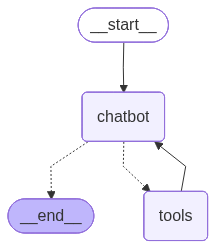

In [19]:
graph = graph_builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [20]:
def chat(user_input: str, history):
    result = graph.invoke({"messages": [{"role": "user", "content": user_input}]})
    return result["messages"][-1].content

In [21]:
gr.ChatInterface(chat, type="messages").launch()

* Running on local URL:  http://127.0.0.1:7865
* To create a public link, set `share=True` in `launch()`.


In [22]:
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()

In [23]:
graph_builder = StateGraph(State)


# Step 3
llm = ChatOpenAI(model="gpt-4o-mini")
llm_with_tools = llm.bind_tools(tools)

In [24]:
llm = ChatOpenAI(model="gpt-4o-mini")
llm_with_tools = llm.bind_tools(tools)

def chatbot(state: State):
    print(state)
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

graph_builder.add_node("chatbot", chatbot)
graph_builder.add_node("tools", ToolNode(tools=tools))

# Step 4
graph_builder.add_conditional_edges( "chatbot", tools_condition, "tools")
graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START, "chatbot")


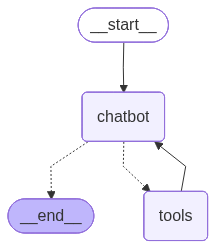

In [25]:
graph = graph_builder.compile(checkpointer=memory)
display(Image(graph.get_graph().draw_mermaid_png()))

In [26]:
config = {"configurable": {"thread_id": "1"}}

def chat(user_input: str, history):
    result = graph.invoke({"messages": [{"role": "user", "content": user_input}]}, config=config)
    return result["messages"][-1].content



In [ ]:
gr.ChatInterface(chat, type="messages").launch()

* Running on local URL:  http://127.0.0.1:7866
* To create a public link, set `share=True` in `launch()`.


{'messages': [HumanMessage(content='my name is ankit', additional_kwargs={}, response_metadata={}, id='dbdd1da2-e3d3-4ff5-ad39-1f7c1d14ce91')]}
{'messages': [HumanMessage(content='my name is ankit', additional_kwargs={}, response_metadata={}, id='dbdd1da2-e3d3-4ff5-ad39-1f7c1d14ce91'), AIMessage(content='Hello, Ankit! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 13, 'prompt_tokens': 94, 'total_tokens': 107, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_476b124e6d', 'id': 'chatcmpl-DKpbz3Zkqsp2ysyo5nBzmXjNYfRqy', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--c153d29d-5b6e-4760-8959-bad847efdbfb-0', usage_metadata={'input_tokens': 94, 'output_tokens': 13, 

In [28]:
graph.get_state(config)

StateSnapshot(values={'messages': [HumanMessage(content='my name is ankit', additional_kwargs={}, response_metadata={}, id='dbdd1da2-e3d3-4ff5-ad39-1f7c1d14ce91'), AIMessage(content='Hello, Ankit! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 13, 'prompt_tokens': 94, 'total_tokens': 107, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_476b124e6d', 'id': 'chatcmpl-DKpbz3Zkqsp2ysyo5nBzmXjNYfRqy', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--c153d29d-5b6e-4760-8959-bad847efdbfb-0', usage_metadata={'input_tokens': 94, 'output_tokens': 13, 'total_tokens': 107, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning'

In [29]:
list(graph.get_state_history(config))

[StateSnapshot(values={'messages': [HumanMessage(content='my name is ankit', additional_kwargs={}, response_metadata={}, id='dbdd1da2-e3d3-4ff5-ad39-1f7c1d14ce91'), AIMessage(content='Hello, Ankit! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 13, 'prompt_tokens': 94, 'total_tokens': 107, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_476b124e6d', 'id': 'chatcmpl-DKpbz3Zkqsp2ysyo5nBzmXjNYfRqy', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--c153d29d-5b6e-4760-8959-bad847efdbfb-0', usage_metadata={'input_tokens': 94, 'output_tokens': 13, 'total_tokens': 107, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning